[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/QuantumMechanics1/blob/main/QM_py/qm1_atomh_hyeprgeom.ipynb)


# Аналітичний розв'язок радіального рівняння атома водню через вироджений гіпергеометричний ряд

Цей ноутбук є додатковим матеріалом до лекцій з квантової механіки для магістрів/аспірантів. Ми використовуємо пакет **SymPy** для математичного перетворення радіального стаціонарного рівняння Шредінгера у вироджене гіпергеометричне рівняння Куммера, перевірки умов обриву ряду та візуалізації радіального розподілу ймовірностей.

## 1. Визначення та перетворення радіального рівняння

Після розділення змінних у сферичних координатах безрозмірне радіальне рівняння для $R(\tilde{r})$ (де $\tilde{r} = r/r_0$) має вигляд:
$$\frac{d^2 R}{d\tilde{r}^2} + \frac{2}{\tilde{r}}\frac{dR}{d\tilde{r}} + \left( \epsilon + \frac{2}{\tilde{r}} - \frac{l(l+1)}{\tilde{r}^2} \right) R = 0$$

Для зв'язаних станів $\epsilon < 0$. Нехай $\kappa = \sqrt{-\epsilon}$. Використовуємо анзац, що враховує асимптотичну поведінку:
$$R(\tilde{r}) = \tilde{r}^l e^{-\kappa \tilde{r}} w(2\kappa \tilde{r})$$

Перевіримо це перетворення за допомогою SymPy, підставивши форму в наше диференціальне рівняння та перейшовши до координати $z = 2\kappa \tilde{r}$.

In [5]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing(use_latex='mathjax')

# Визначення символьних змінних
r, l, kappa, z = sp.symbols('r l kappa z', positive=True)
w = sp.Function('w')

# Анзац для хвильової функції R(r)
R = r**l * sp.exp(-kappa * r) * w(2 * kappa * r)

# Визначення повного оператора радіального рівняння Шредінгера
radial_ode = sp.diff(R, r, 2) + (2/r)*sp.diff(R, r) + (2/r - l*(l+1)/r**2 - kappa**2)*R
radial_ode = sp.simplify(radial_ode)

print("Символьне розкладання похідних виконано успішно.")

Символьне розкладання похідних виконано успішно.


## 2. Обрив ряду та точні зв'язані стани

Вироджене гіпергеометричне рівняння Куммера визначається як:
$$z \frac{d^2 w}{dz^2} + (b - z) \frac{dw}{dz} - a w = 0$$
де:
$$b = 2l + 2$$
$$a = l + 1 - \frac{1}{\kappa}$$

Щоб хвильова функція прямувала до нуля на нескінченності, параметр $a$ має бути обмежений недодатним цілим числом ($a = -n_r$). Це встановлює умову квантування: $\kappa = 1/n$.

Обчислимо явну поліноміальну форму для стану $n=3, l=1$ ($3p$) за допомогою вбудованого інструменту розкладання гіпергеометричних функцій у SymPy.

In [6]:
# Визначення параметрів для 3p-орбіталі
n_val, l_val = 3, 1
kappa_val = sp.Rational(1, n_val)
b_val = 2 * l_val + 2
a_val = l_val + 1 - 1 / kappa_val

print(f"Обчислення для n={n_val}, l={l_val}: a = {a_val}, b = {b_val}")
w_poly = sp.hyperexpand(sp.hyper([a_val], [b_val], z))
print("Отриманий поліном Куммера w(z):")
w_poly

Обчислення для n=3, l=1: a = -1, b = 4
Отриманий поліном Куммера w(z):


    z
1 - ─
    4

## 3. Автоматична генерація нормованих радіальних функцій

Нижче наведено функцію-генератор, яка автоматизує обчислення точного нормованого виразу радіальної хвильової функції для будь-якої валідної комбінації чисел $n$ та $l$.

In [7]:
def get_radial_wavefunction(n, l):
    r_sym = sp.Symbol('r', positive=True)
    kappa_val = sp.Rational(1, n)
    a = l + 1 - n
    b = 2 * l + 2
    
    w_z = sp.hyperexpand(sp.hyper([a], [b], 2 * kappa_val * r_sym))
    R_unnorm = r_sym**l * sp.exp(-kappa_val * r_sym) * w_z
    
    # Обчислення інтеграла нормування по сферичному шару
    norm_integral = sp.integrate(R_unnorm**2 * r_sym**2, (r_sym, 0, sp.oo))
    N = 1 / sp.sqrt(norm_integral)
    
    return sp.simplify(N * R_unnorm)

print("Нормований аналітичний вираз для R_(2,0)(r):")
get_radial_wavefunction(2, 0)

Нормований аналітичний вираз для R_(2,0)(r):


            -r 
            ───
             2 
√2⋅(2 - r)⋅ℯ   
───────────────
       4       

## 4. Побудова графіків радіального розподілу

Просторова густина ймовірності знаходження електрона всередині сферичного шару товщиною $dr$ визначається як $P_{nl}(\tilde{r}) = \tilde{r}^2 R_{nl}^2(\tilde{r})$. Побудуємо ці залежності для аналізу вузлових точок.

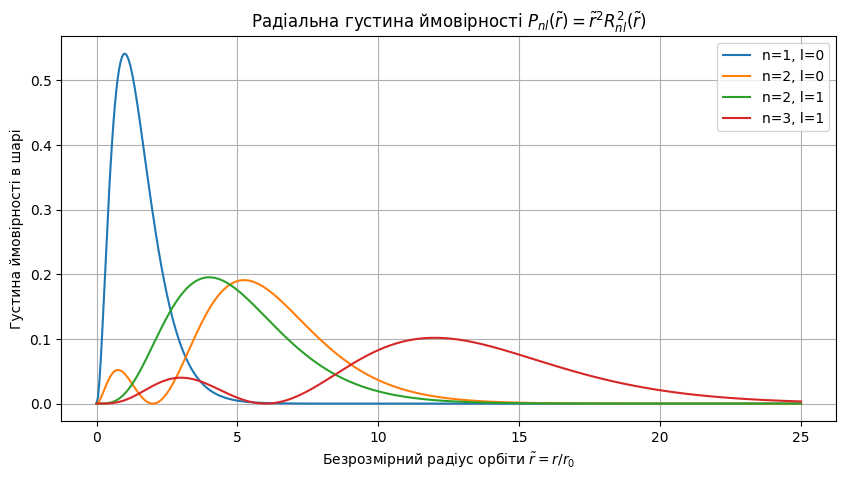

In [8]:
r_sym = sp.Symbol('r', positive=True)
r_vals = np.linspace(0, 25, 500)

plt.figure(figsize=(10, 5))
for n, l in [(1, 0), (2, 0), (2, 1), (3, 1)]:
    R_expression = get_radial_wavefunction(n, l)
    R_numerical = sp.lambdify(r_sym, R_expression, 'numpy')
    
    prob_density = r_vals**2 * (R_numerical(r_vals))**2
    plt.plot(r_vals, prob_density, label=f'n={n}, l={l}')

plt.title("Радіальна густина ймовірності $P_{nl}(\\tilde{r}) = \\tilde{r}^2 R_{nl}^2(\\tilde{r})$")
plt.xlabel("Безрозмірний радіус орбіти $\\tilde{r} = r/r_0$")
plt.ylabel("Густина ймовірності в шарі")
plt.grid(True)
plt.legend()
plt.show()